In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Load the 3 CSV files you created
df_sales = pd.read_csv('ev_sales.csv')
df_sc    = pd.read_csv('service_centers.csv')
df_wc    = pd.read_csv('warranty_claims.csv')

# Check: how many rows and columns does each have?
print("--- Dataset Shapes ---")
print(f"Sales     : {df_sales.shape[0]:,} rows, {df_sales.shape[1]} columns")
print(f"Centers   : {df_sc.shape[0]:,} rows, {df_sc.shape[1]} columns")
print(f"Warranty  : {df_wc.shape[0]:,} rows, {df_wc.shape[1]} columns")

# Check column names — make sure they match what you expect
print("\n--- Column Names ---")
print("Sales:", df_sales.columns.tolist())
print("Centers:", df_sc.columns.tolist())
print("Warranty:", df_wc.columns.tolist())

# Preview first 2 rows of sales data
df_sales.head(2)

--- Dataset Shapes ---
Sales     : 10,000 rows, 9 columns
Centers   : 7,200 rows, 11 columns
Warranty  : 50,000 rows, 8 columns

--- Column Names ---
Sales: ['vehicle_id', 'oem', 'model', 'state', 'city_tier', 'sale_date', 'sale_price_lakh', 'battery_kwh', 'warranty_years']
Centers: ['center_id', 'oem', 'city_tier', 'month', 'monthly_jobs', 'avg_job_value', 'parts_revenue', 'labor_revenue', 'fixed_cost_monthly', 'technician_count', 'ota_deflections']
Warranty: ['claim_id', 'vehicle_id', 'component', 'months_in_service', 'repair_cost', 'climate_zone', 'root_cause', 'avoidable_ota']


,vehicle_id,oem,model,state,city_tier,sale_date,sale_price_lakh,battery_kwh,warranty_years
0,VH00000,Tata,Nexon EV,UP,3,2022-01-01 00:00:00.000000,17.9,40.0,5
1,VH00001,MG,ZS EV,RJ,3,2022-01-01 02:37:41.746174,18.3,27.1,3


In [4]:
# Count vehicles sold per OEM
oem_counts = df_sales['oem'].value_counts()

# Convert to percentage
oem_pct = (oem_counts / oem_counts.sum() * 100).round(1)

# Show both together in one table
oem_summary = pd.DataFrame({
    'Vehicles Sold': oem_counts,
    'Market Share %': oem_pct
})
print(oem_summary)

         Vehicles Sold  Market Share %
oem                                   
Tata              5310            53.1
Ola               1497            15.0
Hyundai           1354            13.5
BYD                973             9.7
MG                 866             8.7


In [7]:
tier_counts = df_sales['city_tier'].value_counts().sort_index()
tier_pct    = (tier_counts / tier_counts.sum() * 100).round(1)

tier_summary = pd.DataFrame({
    'City Tier': ['Tier 1 (Metro)', 'Tier 2 (Mid)', 'Tier 3 (Small)'],
    'Vehicles Sold': tier_counts.values,
    'Share %': tier_pct.values
})
print(tier_summary.to_string(index=False))

# Cross table: which OEM sells in which tier?
print("\nOEM vs City Tier breakdown:")
cross = pd.crosstab(df_sales['oem'], df_sales['city_tier'])
print(cross)

     City Tier  Vehicles Sold  Share %
Tier 1 (Metro)           3688     36.9
  Tier 2 (Mid)           3715     37.2
Tier 3 (Small)           2597     26.0

OEM vs City Tier breakdown:
city_tier     1     2     3
oem                        
BYD         361   358   254
Hyundai     514   509   331
MG          329   320   217
Ola         560   549   388
Tata       1924  1979  1407


In [9]:
# Real India EV annual sales figures + projections
# Source: SMEV 2023-24 actuals, NITI Aayog projections
years      = [2022,2023,2024,2025,2026,2027,2028,2029,2030]
annual_sales = [46000,92000,175000,340000,
                580000,820000,1100000,1450000,1800000]

# Cumulative fleet = all cars ever sold that are still on roads
cumulative_fleet = np.cumsum(annual_sales)

# Avg aftersales spend per vehicle per year = Rs 8,500
# (based on Maruti/Tata aftersales revenue / fleet size benchmarks)
spend_per_vehicle = 8500

# Market size in Crore
market_cr = (cumulative_fleet * spend_per_vehicle) / 1e7

df_tam = pd.DataFrame({
    'Year':             years,
    'Annual Sales':     [f'{x:,}' for x in annual_sales],
    'Cumulative Fleet': [f'{x:,}' for x in cumulative_fleet],
    'Aftersales TAM (Cr)': market_cr.round(0).astype(int)
})

print(df_tam.to_string(index=False))
print(f"\nFY30 Aftersales Market = Rs {market_cr[-1]:,.0f} Crore")

 Year Annual Sales Cumulative Fleet  Aftersales TAM (Cr)
 2022       46,000           46,000                   39
 2023       92,000          138,000                  117
 2024      175,000          313,000                  266
 2025      340,000          653,000                  555
 2026      580,000        1,233,000                 1048
 2027      820,000        2,053,000                 1745
 2028    1,100,000        3,153,000                 2680
 2029    1,450,000        4,603,000                 3913
 2030    1,800,000        6,403,000                 5443

FY30 Aftersales Market = Rs 5,443 Crore


In [11]:
# Total monthly revenue = jobs × average job value
df_sc['total_revenue'] = df_sc['monthly_jobs'] * df_sc['avg_job_value']

# Contribution margin = 45% of revenue (industry benchmark)
df_sc['contribution'] = df_sc['total_revenue'] * 0.45

# Monthly profit = contribution - fixed costs
df_sc['monthly_profit'] = df_sc['contribution'] - df_sc['fixed_cost_monthly']

# Flag: is this center profitable this month?
df_sc['is_profitable'] = df_sc['monthly_profit'] > 0

# Breakeven jobs = how many jobs needed to cover fixed costs
df_sc['breakeven_jobs'] = (
    df_sc['fixed_cost_monthly'] / (df_sc['avg_job_value'] * 0.45)
).round(0)

# Preview the new columns
df_sc[['center_id','city_tier','monthly_jobs','total_revenue',
       'monthly_profit','breakeven_jobs','is_profitable']].head(5)

,center_id,city_tier,monthly_jobs,total_revenue,monthly_profit,breakeven_jobs,is_profitable
0,SC000,3,105,465990,25090.50,92.0,True
1,SC000,3,84,370440,-50410.00,109.0,False
2,SC000,3,86,350708,-14241.40,94.0,False
3,SC000,3,83,491277,36130.65,69.0,True
4,SC000,3,124,608964,94677.80,81.0,True


In [13]:
# For each center, avg across all 36 months
center_avg = df_sc.groupby('center_id').agg(
    city_tier       = ('city_tier', 'first'),
    avg_profit      = ('monthly_profit', 'mean'),
    avg_jobs        = ('monthly_jobs', 'mean'),
    avg_breakeven   = ('breakeven_jobs', 'mean'),
    pct_months_loss = ('is_profitable', lambda x: (~x).mean() * 100)
).reset_index()

# Summary by tier
tier_summary = center_avg.groupby('city_tier').agg(
    num_centers       = ('center_id', 'count'),
    avg_monthly_profit= ('avg_profit', 'mean'),
    avg_actual_jobs   = ('avg_jobs', 'mean'),
    avg_breakeven_jobs= ('avg_breakeven', 'mean'),
    pct_loss_months   = ('pct_months_loss', 'mean')
).round(1)

tier_summary.index = ['Tier 1 (Metro)','Tier 2 (Mid-City)','Tier 3 (Small City)']
print(tier_summary.to_string())

                     num_centers  avg_monthly_profit  avg_actual_jobs  avg_breakeven_jobs  pct_loss_months
Tier 1 (Metro)                60            153927.3            180.2               134.1              4.9
Tier 2 (Mid-City)             77             31936.7            119.3               107.7             34.1
Tier 3 (Small City)           63            -36534.0             69.5                88.3             74.3


In [15]:
# Total OTA deflections across all centers
total_ota = df_sc['ota_deflections'].sum()
print(f"Total OTA deflections (36 months): {total_ota:,}")

# Value of each deflection = avg job value avoided
avg_job_val = df_sc['avg_job_value'].mean()
ota_value   = total_ota * avg_job_val
print(f"Avg job value: Rs {avg_job_val:,.0f}")
print(f"Total OTA savings over 3 years: Rs {ota_value/1e7:.1f} Crore")
print(f"Per year: Rs {ota_value/3/1e7:.1f} Crore")

# OTA deflections by tier
ota_by_tier = df_sc.groupby('city_tier')['ota_deflections'].mean().round(1)
print("\nAvg monthly OTA deflections per center by tier:")
print(ota_by_tier)

Total OTA deflections (36 months): 213,013
Avg job value: Rs 5,840
Total OTA savings over 3 years: Rs 124.4 Crore
Per year: Rs 41.5 Crore

Avg monthly OTA deflections per center by tier:
city_tier
1    29.5
2    29.6
3    29.7
Name: ota_deflections, dtype: float64


In [17]:
# Group warranty claims by component
comp_analysis = df_wc.groupby('component').agg(
    num_claims    = ('claim_id', 'count'),
    total_cost_rs = ('repair_cost', 'sum'),
    avg_cost_rs   = ('repair_cost', 'mean')
).sort_values('total_cost_rs', ascending=False)

# Convert to Crore for readability
comp_analysis['total_cost_cr'] = (comp_analysis['total_cost_rs'] / 1e7).round(1)
comp_analysis['avg_cost_rs']    = comp_analysis['avg_cost_rs'].round(0).astype(int)

# Share of total cost
total = comp_analysis['total_cost_rs'].sum()
comp_analysis['cost_share_%'] = (comp_analysis['total_cost_rs'] / total * 100).round(1)

print(comp_analysis[['num_claims','avg_cost_rs','total_cost_cr','cost_share_%']].to_string())

                   num_claims  avg_cost_rs  total_cost_cr  cost_share_%
component                                                              
Battery                 17361        59474          103.3          54.3
Motor                   10087        37741           38.1          20.0
Power Electronics       10017        30139           30.2          15.9
HVAC                     7488        19265           14.4           7.6
Charging Port            5047         8604            4.3           2.3


In [19]:
# Split into avoidable vs not avoidable
ota_split = df_wc.groupby('avoidable_ota').agg(
    claims    = ('claim_id', 'count'),
    total_cost= ('repair_cost', 'sum')
)
ota_split['cost_cr']    = (ota_split['total_cost'] / 1e7).round(1)
ota_split['claims_pct'] = (ota_split['claims'] / ota_split['claims'].sum() * 100).round(1)
print(ota_split[['claims','claims_pct','cost_cr']])

# Which component benefits most from OTA?
print("\nOTA-avoidable rate by component:")
ota_by_comp = df_wc.groupby('component')['avoidable_ota'].mean().sort_values(ascending=False)
print((ota_by_comp * 100).round(1).astype(str) + '%')

               claims  claims_pct  cost_cr
avoidable_ota                             
False           33713        67.4    120.1
True            16287        32.6     70.1

OTA-avoidable rate by component:
component
Battery              45.1%
Power Electronics    40.0%
Charging Port        20.0%
HVAC                 19.7%
Motor                19.5%
Name: avoidable_ota, dtype: str


In [20]:
# Filter only battery claims
battery_claims = df_wc[df_wc['component'] == 'Battery']

# Count claims and avg cost by climate zone
climate_analysis = battery_claims.groupby('climate_zone').agg(
    claims   = ('claim_id', 'count'),
    avg_cost = ('repair_cost', 'mean'),
    total_cr = ('repair_cost', lambda x: x.sum()/1e7)
).round(1)

# Rate per claim (normalised)
climate_analysis['claim_rate_index'] = (
    climate_analysis['claims'] / climate_analysis['claims'].min()
).round(2)

print(climate_analysis.to_string())

              claims  avg_cost  total_cr  claim_rate_index
climate_zone                                              
Hot-Dry         6101   59366.4      36.2              1.42
Hot-Humid       6950   59290.0      41.2              1.61
Temperate       4310   59923.1      25.8              1.00


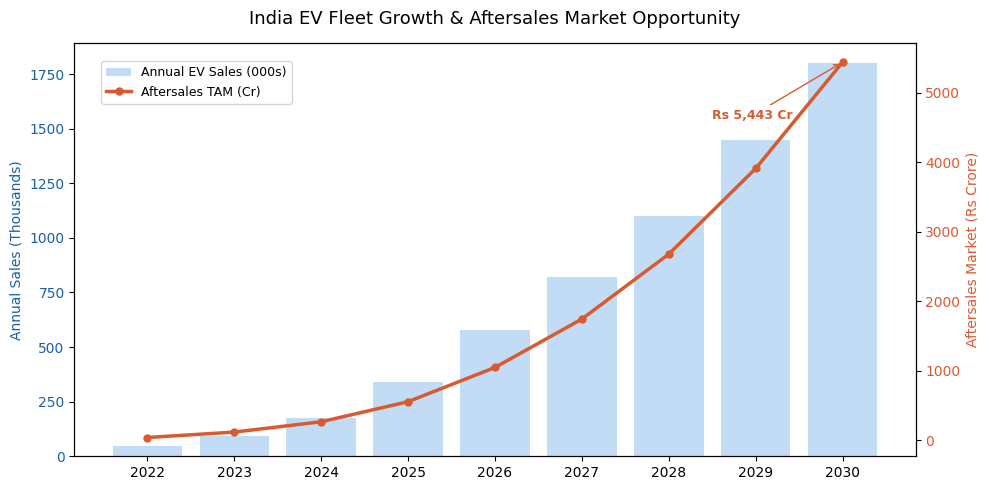

Saved: chart1_market_growth.png


In [21]:
years        = [2022,2023,2024,2025,2026,2027,2028,2029,2030]
annual_sales = [46000,92000,175000,340000,580000,820000,1100000,1450000,1800000]
market_cr    = (np.cumsum(annual_sales) * 8500) / 1e7

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart for annual sales
ax1.bar(years, [x/1000 for x in annual_sales],
        color='#B5D4F4', alpha=0.8, label='Annual EV Sales (000s)')
ax1.set_ylabel('Annual Sales (Thousands)', color='#185FA5')
ax1.tick_params(axis='y', labelcolor='#185FA5')

# Line chart for market size on second axis
ax2 = ax1.twinx()
ax2.plot(years, market_cr, color='#D85A30', marker='o',
         linewidth=2.5, markersize=5, label='Aftersales TAM (Cr)')
ax2.set_ylabel('Aftersales Market (Rs Crore)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')

# Annotation on final data point
ax2.annotate(f'Rs {market_cr[-1]:,.0f} Cr',
             xy=(2030, market_cr[-1]),
             xytext=(2028.5, market_cr[-1]*0.85),
             fontsize=9, color='#D85A30', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#D85A30'))

ax1.set_title('India EV Fleet Growth & Aftersales Market Opportunity', fontsize=13, pad=14)
ax1.set_xticks(years)
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.88), fontsize=9)
plt.tight_layout()
plt.savefig('chart1_market_growth.png', dpi=150)
plt.show()
print("Saved: chart1_market_growth.png")

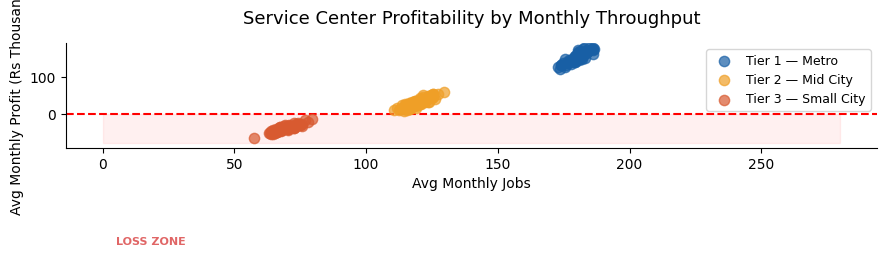

Saved: chart2_dealer_profit.png


In [22]:
# Use the center_avg table you made in Analysis 2b
fig, ax = plt.subplots(figsize=(9, 6))

colors = {1:'#185FA5', 2:'#EF9F27', 3:'#D85A30'}
labels = {1:'Tier 1 — Metro', 2:'Tier 2 — Mid City', 3:'Tier 3 — Small City'}

for tier, grp in center_avg.groupby('city_tier'):
    ax.scatter(grp['avg_jobs'],
               grp['avg_profit'] / 1000,
               color=colors[tier], label=labels[tier],
               alpha=0.7, s=55, zorder=3)

# Breakeven line
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, zorder=2)
ax.fill_between([0,280], 0, ax.get_ylim()[0] if ax.get_ylim()[0] < 0 else -400,
                alpha=0.06, color='red', zorder=1)
ax.text(5, -350, 'LOSS ZONE', color='#cc0000', fontsize=8,
        fontweight='bold', alpha=0.6)

ax.set_title('Service Center Profitability by Monthly Throughput', fontsize=13, pad=14)
ax.set_xlabel('Avg Monthly Jobs')
ax.set_ylabel('Avg Monthly Profit (Rs Thousands)')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart2_dealer_profit.png', dpi=150)
plt.show()
print("Saved: chart2_dealer_profit.png")

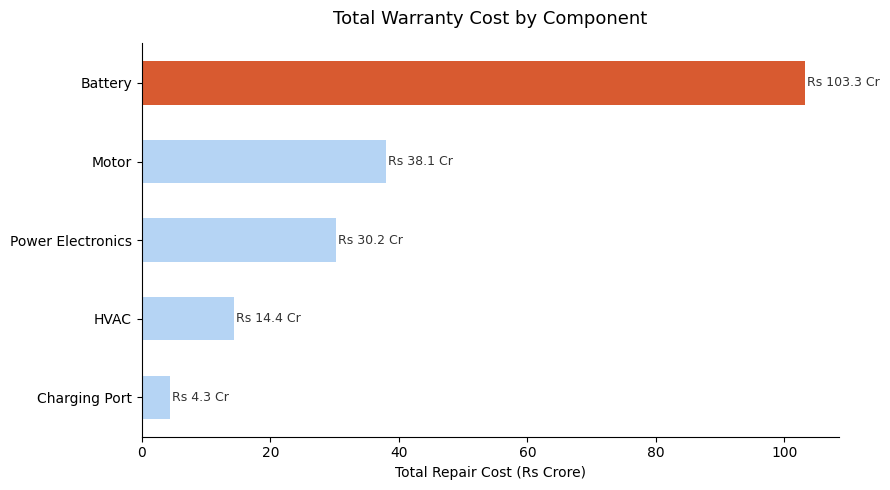

Saved: chart3_warranty.png


In [23]:
comp_cost = df_wc.groupby('component')['repair_cost'].sum().sort_values() / 1e7

fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = ['#D85A30' if c == 'Battery' else '#B5D4F4' for c in comp_cost.index]
bars = ax.barh(comp_cost.index, comp_cost.values, color=bar_colors, height=0.55)

for bar in bars:
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'Rs {bar.get_width():.1f} Cr',
            va='center', fontsize=9, color='#333')

ax.set_title('Total Warranty Cost by Component', fontsize=13, pad=14)
ax.set_xlabel('Total Repair Cost (Rs Crore)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_warranty.png', dpi=150)
plt.show()
print("Saved: chart3_warranty.png")

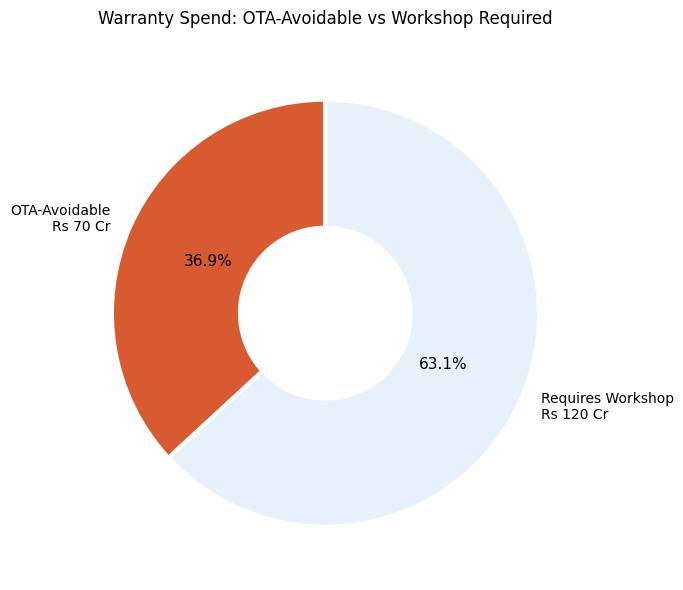

Saved: chart4_ota.png


In [24]:
ota_yes = df_wc[df_wc['avoidable_ota']==True]['repair_cost'].sum() / 1e7
ota_no  = df_wc[df_wc['avoidable_ota']==False]['repair_cost'].sum() / 1e7

fig, ax = plt.subplots(figsize=(7, 6))

wedges, texts, autotexts = ax.pie(
    [ota_yes, ota_no],
    labels=[f'OTA-Avoidable\nRs {ota_yes:.0f} Cr', f'Requires Workshop\nRs {ota_no:.0f} Cr'],
    autopct='%1.1f%%',
    colors=['#D85A30', '#E6F1FB'],
    startangle=90,
    wedgeprops={'linewidth':3, 'edgecolor':'white', 'width':0.6}
)
for t in autotexts: t.set_fontsize(11)

ax.set_title('Warranty Spend: OTA-Avoidable vs Workshop Required', fontsize=12, pad=16)
plt.tight_layout()
plt.savefig('chart4_ota.png', dpi=150)
plt.show()
print("Saved: chart4_ota.png")